In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import root_mean_squared_error

In [2]:
# Load data
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Data/cell_cycle_tidied.csv")

# Define features and target
X = df.drop(columns=['phase', 'age', 'PHATE_1', 'PHATE_2'])  # Features
y = df['age']  # Target: age

feature_names = X.columns.tolist()
X = X.to_numpy()
y = y.to_numpy()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=949
)

LOCO

In [3]:
import sys
sys.path.append("/Users/mariahloehr/IICD/IICD/feature_importance")

In [4]:
import locomp
from locomp import *
from locomp.MLmodels import *
import itertools
import importlib
from sklearn.base import BaseEstimator, RegressorMixin, clone
import itertools
from functools import partial
import multiprocessing as mp
import re

In [5]:
# define fit_func
def MLPreg(X,Y,X1):
    mlp = MLPRegressor(max_iter=200,
                       random_state=949,
                       hidden_layer_sizes = (150,150,150),
                       learning_rate = 'adaptive', 
                       learning_rate_init = 0.001, 
                       alpha = 25).fit(X,Y)
    return mlp.predict(X1)

In [6]:
J1 = 0
J2 = 1
m_ratio = 0.6
n_ratio = 0.6
B = 5000
fit_func = MLPreg

In [20]:
x=LOCOMPReg(X,y,n_ratio,m_ratio,B,fit_func, selected_features=[],alpha=0.1,bonf=True)
x.run_loco()
#x.loco_ci

In [21]:
import re

def rename_feature(name):
    match = re.match(r"(\w+)\.\.(nuc|cyto)\.\w+\.", name)
    if match:
        protein, location = match.groups()
        location_full = 'nucleus' if location == 'nuc' else 'cytoplasm'
        return f"{protein} ({location_full})"
    return name  # leave unchanged if it doesn't match the pattern

# Apply renaming
renamed_features = [rename_feature(col) for col in feature_names]

In [22]:
ci_df = pd.DataFrame(x.loco_ci)
ci_df = ci_df.rename(columns={2: 'lower_bound', 3: 'upper_bound', 4: 'score'})
ci_df['feature_name'] = renamed_features
fig_df = ci_df.nlargest(10, "score")
fig_df.replace('Nuc.area', 'Area (nucleus)', inplace=True)
fig_df.replace('p21..phospho.total.nuc.', 'p21 phospho (nucleus)', inplace=True)

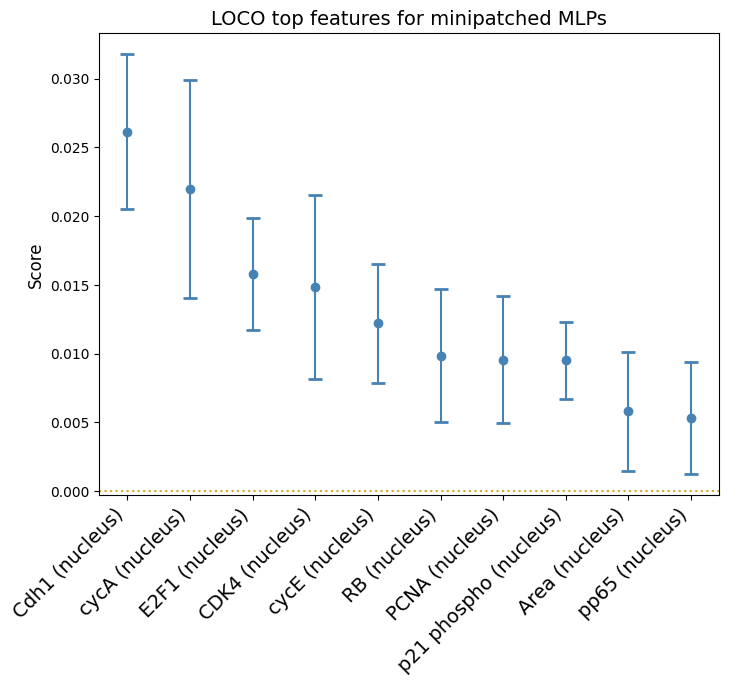

In [23]:
# Plot
plt.figure(figsize=(8, 6))
plt.errorbar(
    fig_df["feature_name"], fig_df["score"],
    yerr=[fig_df["score"] - fig_df["lower_bound"], fig_df["upper_bound"] - fig_df["score"]],
    fmt="o", capsize=5, capthick=2, markersize=6, color="steelblue"
)
plt.axhline(y=0, color='goldenrod', linestyle='dotted')
plt.title("LOCO top features for minipatched MLPs", fontsize=14)
plt.ylabel("Score", fontsize=12)
plt.xticks(rotation=45, fontsize=14, ha = 'right')
plt.show()

In [11]:
ci_df.to_csv('/Users/mariahloehr/IICD/IICD/LOCO/mlp_.2loco_importances.csv', index=False)